# Customer Churn Prediction using KNN

## 1. Project Overview

### Problem Statement
The goal of this project is to build a Machine Learning model
that predicts whether a customer will leave a telecommunications
company or continue using its services.

### Machine Learning Problem
This is a Supervised Learning problem.

The target variable represents whether a customer churns or not,
so this is a Binary Classification problem.

### Objective
Build an end-to-end Machine Learning solution that:
- Understands and analyzes the dataset.
- Performs data cleaning and preprocessing.
- Applies K-Nearest Neighbors (KNN).
- Evaluates the model using appropriate classification metrics.
- Performs error analysis.
- Tunes the model hyperparameters.
- Saves the trained model pipeline.
- Deploys the model using Streamlit.

In [4]:
import kagglehub

path = kagglehub.dataset_download(
    "blastchar/telco-customer-churn"
)

print("Dataset path:", path)

Dataset path: C:\Users\Abdel\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [5]:
import shutil
import os

source_path = r"C:\Users\Abdel\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1\WA_Fn-UseC_-Telco-Customer-Churn.csv"

destination_folder = r"../data/raw"
destination_path = os.path.join(
    destination_folder,
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

os.makedirs(destination_folder, exist_ok=True)

shutil.copy2(source_path, destination_path)

print("Dataset copied successfully.")
print("Saved at:", destination_path)

Dataset copied successfully.
Saved at: ../data/raw\WA_Fn-UseC_-Telco-Customer-Churn.csv


In [6]:
import os

dataset_path = r"C:\Users\Abdel\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1"

print(os.listdir(dataset_path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [32]:
import pandas as pd

df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [8]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Shape:", df.shape)

Rows: 7043
Columns: 21
Shape: (7043, 21)


In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
total_charges_numeric = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

print("Non-numeric / invalid values:")
print(df.loc[total_charges_numeric.isna(), "TotalCharges"])

print("\nCount:", total_charges_numeric.isna().sum())

Non-numeric / invalid values:
488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: str

Count: 11


In [14]:
invalid_total_charges = total_charges_numeric.isna()

df.loc[
    invalid_total_charges,
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [15]:
print(
    df.loc[
        total_charges_numeric.isna(),
        "tenure"
    ].value_counts()
)

tenure
0    11
Name: count, dtype: int64


In [16]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [17]:
print(df["TotalCharges"].dtype)
print("Missing values:", df["TotalCharges"].isnull().sum())

float64
Missing values: 0


In [20]:
categorical_columns = df.select_dtypes(include=["str"]).columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].unique())


customerID:
<ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtecti

In [21]:
for col in categorical_columns:
    if col != "customerID":
        print(f"{col}:")
        print("Number of unique values:", df[col].nunique())
        print("Values:", df[col].unique())
        print("-" * 50)

gender:
Number of unique values: 2
Values: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
Partner:
Number of unique values: 2
Values: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Dependents:
Number of unique values: 2
Values: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
PhoneService:
Number of unique values: 2
Values: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
MultipleLines:
Number of unique values: 3
Values: <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
--------------------------------------------------
InternetService:
Number of unique values: 3
Values: <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
--------------------------------------------------
OnlineSecurity:
Number of unique values

In [22]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "unique_values": df.nunique(),
    "missing_values": df.isnull().sum()
})

summary

,dtype,unique_values,missing_values
customerID,str,7043,0
gender,str,2,0
SeniorCitizen,int64,2,0
Partner,str,2,0
Dependents,str,2,0
tenure,int64,73,0
PhoneService,str,2,0
MultipleLines,str,3,0
InternetService,str,3,0
OnlineSecurity,str,3,0


In [23]:
print(df["Churn"].value_counts())

print("\nPercentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [24]:
df[
    ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]
].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


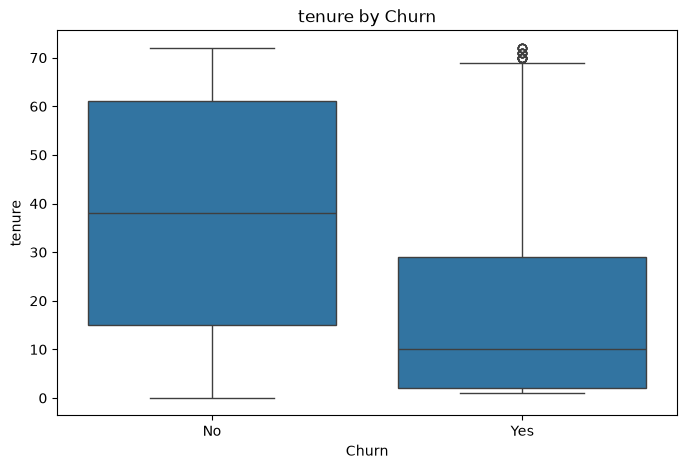

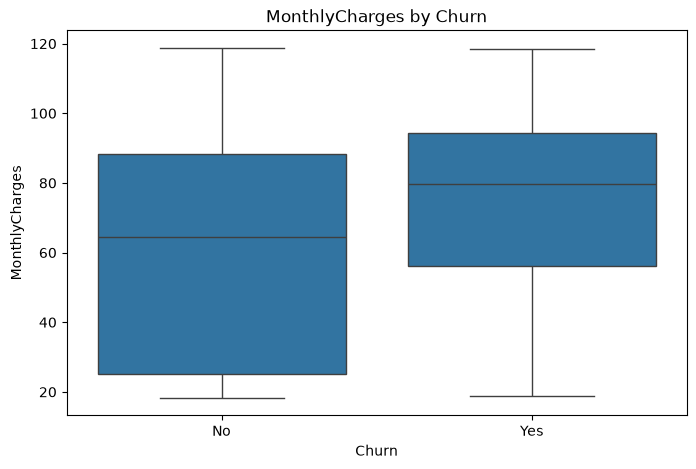

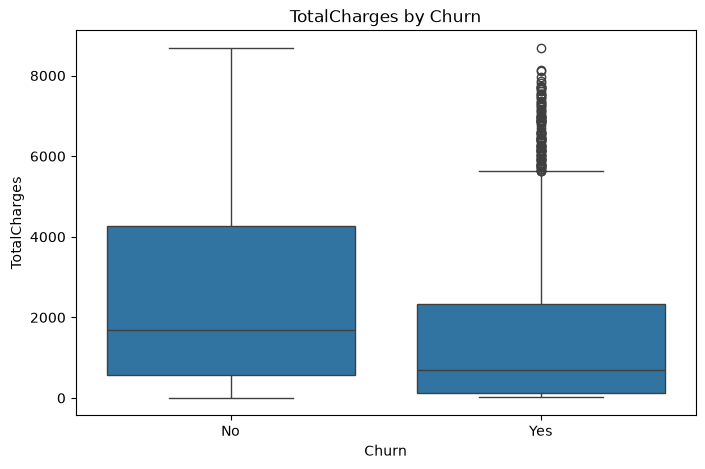

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

for feature in numerical_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="Churn",
        y=feature
    )

    plt.title(f"{feature} by Churn")
    plt.xlabel("Churn")
    plt.ylabel(feature)

    plt.show()

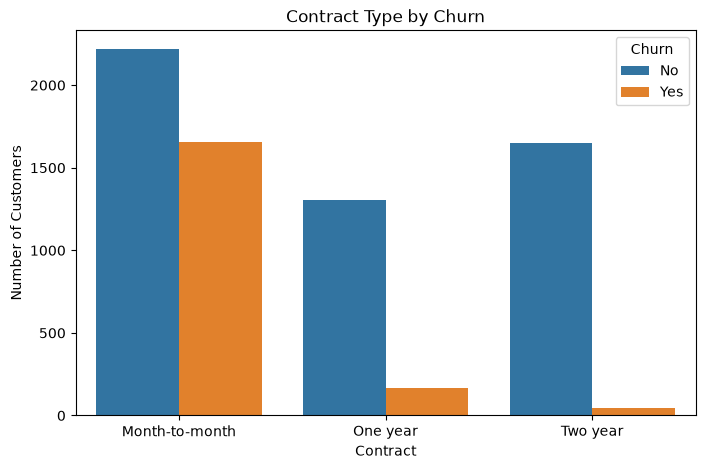

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type by Churn")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.show()

In [28]:
contract_churn_rate = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn_rate

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [29]:
internet_churn_rate = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

internet_churn_rate

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [30]:
payment_churn_rate = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

payment_churn_rate

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [31]:
service_features = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for feature in service_features:
    print(f"\n{feature}")
    
    result = pd.crosstab(
        df[feature],
        df["Churn"],
        normalize="index"
    ) * 100
    
    print(result)


OnlineSecurity
Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194

OnlineBackup
Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494

DeviceProtection
Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064

TechSupport
Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341

StreamingTV
Churn                       No        Yes
StreamingTV                              
No

In [39]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [42]:
print("TotalCharges dtype:", X_train["TotalCharges"].dtype)

print("\nInvalid TotalCharges values:")
print(
    X_train.loc[
        pd.to_numeric(
            X_train["TotalCharges"],
            errors="coerce"
        ).isna(),
        "TotalCharges"
    ]
)

TotalCharges dtype: str

Invalid TotalCharges values:
6670     
4380     
3826     
488      
1082     
1340     
6754     
3331     
Name: TotalCharges, dtype: str


In [43]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isna().sum())

float64
0


In [44]:
X = df.drop("Churn", axis=1)

X = X.drop("customerID", axis=1)

y = df["Churn"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5634, 19)
X_test shape: (1409, 19)


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [47]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)

X_train_processed shape: (5634, 46)
X_test_processed shape: (1409, 46)


In [48]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_processed,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['No','Yes']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [49]:
y_pred = knn_model.predict(X_test_processed)

y_pred_proba = knn_model.predict_proba(X_test_processed)[:, 1]

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="Yes")
recall = recall_score(y_test, y_pred, pos_label="Yes")
f1 = f1_score(y_test, y_pred, pos_label="Yes")
roc_auc = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_pred_proba
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.7572746628814763
Precision: 0.5418848167539267
Recall   : 0.553475935828877
F1 Score : 0.5476190476190477
ROC-AUC  : 0.788330879123718


In [52]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[860 175]
 [167 207]]


In [53]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = range(1, 31)

cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k
    )
    
    scores = cross_val_score(
        knn,
        X_train_processed,
        y_train,
        cv=5,
        scoring="roc_auc"
    )
    
    cv_scores.append(scores.mean())

print("Best K:", k_values[cv_scores.index(max(cv_scores))])
print("Best CV ROC-AUC:", max(cv_scores))

Best K: 30
Best CV ROC-AUC: 0.8360610656988458


In [54]:
best_knn = KNeighborsClassifier(
    n_neighbors=30
)

best_knn.fit(
    X_train_processed,
    y_train
)

y_pred_best = best_knn.predict(X_test_processed)

y_pred_best_proba = best_knn.predict_proba(
    X_test_processed
)[:, 1]

In [55]:
accuracy_best = accuracy_score(y_test, y_pred_best)

precision_best = precision_score(
    y_test,
    y_pred_best,
    pos_label="Yes"
)

recall_best = recall_score(
    y_test,
    y_pred_best,
    pos_label="Yes"
)

f1_best = f1_score(
    y_test,
    y_pred_best,
    pos_label="Yes"
)

roc_auc_best = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_pred_best_proba
)

print("Accuracy :", accuracy_best)
print("Precision:", precision_best)
print("Recall   :", recall_best)
print("F1 Score :", f1_best)
print("ROC-AUC  :", roc_auc_best)

Accuracy : 0.7877927608232789
Precision: 0.6112759643916914
Recall   : 0.5508021390374331
F1 Score : 0.5794655414908579
ROC-AUC  : 0.8310250846056472


In [56]:
cm_best = confusion_matrix(
    y_test,
    y_pred_best,
    labels=["No", "Yes"]
)

print("Confusion Matrix:")
print(cm_best)


Confusion Matrix:
[[904 131]
 [168 206]]


In [57]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

weights_results = {}

for weights in ["uniform", "distance"]:
    knn = KNeighborsClassifier(
        n_neighbors=30,
        weights=weights
    )
    
    scores = cross_val_score(
        knn,
        X_train_processed,
        y_train,
        cv=5,
        scoring="roc_auc"
    )
    
    weights_results[weights] = scores.mean()

print("CV ROC-AUC results:")

for weights, score in weights_results.items():
    
    print(f"{weights}: {score:.4f}")

CV ROC-AUC results:
uniform: 0.8361
distance: 0.8183


In [58]:
p_results = {}

for p in [1, 2]:
    knn = KNeighborsClassifier(
        n_neighbors=30,
        weights="uniform",
        p=p
    )
    
    scores = cross_val_score(
        knn,
        X_train_processed,
        y_train,
        cv=5,
        scoring="roc_auc"
    )
    
    p_results[p] = scores.mean()

print("CV ROC-AUC results:")

for p, score in p_results.items():
    print(f"p={p}: {score:.4f}")

CV ROC-AUC results:
p=1: 0.8347
p=2: 0.8361


In [59]:
final_knn = KNeighborsClassifier(
    n_neighbors=30,
    weights="uniform",
    p=2
)

final_knn.fit(
    X_train_processed,
    y_train
)

y_pred_final = final_knn.predict(X_test_processed)

y_pred_proba_final = final_knn.predict_proba(
    X_test_processed
)[:, 1]

In [60]:
final_accuracy = accuracy_score(y_test, y_pred_final)

final_precision = precision_score(
    y_test,
    y_pred_final,
    pos_label="Yes"
)

final_recall = recall_score(
    y_test,
    y_pred_final,
    pos_label="Yes"
)

final_f1 = f1_score(
    y_test,
    y_pred_final,
    pos_label="Yes"
)

final_roc_auc = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_pred_proba_final
)

print("Final KNN Results")
print("-----------------")
print("Accuracy :", final_accuracy)
print("Precision:", final_precision)
print("Recall   :", final_recall)
print("F1 Score :", final_f1)
print("ROC-AUC  :", final_roc_auc)

Final KNN Results
-----------------
Accuracy : 0.7877927608232789
Precision: 0.6112759643916914
Recall   : 0.5508021390374331
F1 Score : 0.5794655414908579
ROC-AUC  : 0.8310250846056472


In [61]:
final_cm = confusion_matrix(
    y_test,
    y_pred_final,
    labels=["No", "Yes"]
)

print("Confusion Matrix:")
print(final_cm)

Confusion Matrix:
[[904 131]
 [168 206]]


In [62]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test
error_analysis["Predicted"] = y_pred_final

error_analysis["Error_Type"] = "Correct"

error_analysis.loc[
    (error_analysis["Actual"] == "Yes") &
    (error_analysis["Predicted"] == "No"),
    "Error_Type"
] = "False Negative"

error_analysis.loc[
    (error_analysis["Actual"] == "No") &
    (error_analysis["Predicted"] == "Yes"),
    "Error_Type"
] = "False Positive"

print(error_analysis["Error_Type"].value_counts())

Error_Type
Correct           1110
False Negative     168
False Positive     131
Name: count, dtype: int64


In [63]:
false_negatives = error_analysis[
    error_analysis["Error_Type"] == "False Negative"
]

print("False Negatives:", len(false_negatives))

display(false_negatives.head())

False Negatives: 168


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Actual,Predicted,Error_Type
950,Male,1,No,No,2,Yes,No,DSL,No,No,...,No,No,Month-to-month,No,Mailed check,44.95,85.15,Yes,No,False Negative
2488,Male,0,No,No,31,Yes,No,DSL,No,No,...,No,No,Month-to-month,Yes,Electronic check,55.25,1715.65,Yes,No,False Negative
523,Female,0,No,No,23,Yes,Yes,Fiber optic,No,No,...,No,No,Month-to-month,No,Bank transfer (automatic),75.60,1758.60,Yes,No,False Negative
5086,Male,0,No,No,45,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,One year,Yes,Electronic check,20.40,930.45,Yes,No,False Negative
3408,Female,0,No,No,4,Yes,No,DSL,No,Yes,...,No,No,Month-to-month,No,Credit card (automatic),50.70,151.30,Yes,No,False Negative


In [64]:
false_negatives[
    ["tenure", "MonthlyCharges", "TotalCharges"]
].describe()

,tenure,MonthlyCharges,TotalCharges
count,168.000000,168.000000,168.000000
mean,24.654762,64.786607,2082.287500
std,22.269979,30.058857,2258.928258
min,1.000000,18.950000,19.300000
25%,3.000000,44.875000,111.462500
50%,18.000000,60.375000,1284.950000
75%,42.750000,93.875000,3283.612500
max,72.000000,115.650000,7968.850000


In [65]:
true_positives = error_analysis[
    (error_analysis["Actual"] == "Yes") &
    (error_analysis["Predicted"] == "Yes")
]

print("False Negatives:", len(false_negatives))
print("True Positives:", len(true_positives))

False Negatives: 168
True Positives: 206


In [66]:
comparison = pd.DataFrame({
    "False Negatives": false_negatives[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].mean(),
    
    "True Positives": true_positives[
        ["tenure", "MonthlyCharges", "TotalCharges"]
    ].mean()
})

print(comparison)

                False Negatives  True Positives
tenure                24.654762        9.781553
MonthlyCharges        64.786607       79.275485
TotalCharges        2082.287500      844.872330


In [67]:
contract_comparison = pd.crosstab(
    error_analysis["Contract"],
    error_analysis["Error_Type"],
    normalize="columns"
) * 100

print(contract_comparison)

Error_Type        Correct  False Negative  False Positive
Contract                                                 
Month-to-month  47.207207       73.214286       96.183206
One year        23.423423       21.428571        3.053435
Two year        29.369369        5.357143        0.763359


In [68]:
payment_comparison = pd.crosstab(
    error_analysis["PaymentMethod"],
    error_analysis["Error_Type"],
    normalize="columns"
) * 100

print(payment_comparison)

Error_Type                   Correct  False Negative  False Positive
PaymentMethod                                                       
Bank transfer (automatic)  22.702703       22.619048        7.633588
Credit card (automatic)    24.144144       17.261905        9.160305
Electronic check           29.819820       33.928571       65.648855
Mailed check               23.333333       26.190476       17.557252


In [69]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_final,
        labels=["No", "Yes"]
    )
)

              precision    recall  f1-score   support

          No       0.84      0.87      0.86      1035
         Yes       0.61      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [70]:
from sklearn.pipeline import Pipeline

final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("knn", KNeighborsClassifier(
            n_neighbors=30,
            weights="uniform",
            p=2
        ))
    ]
)

print(final_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                               

In [71]:
final_pipeline.fit(
    X_train,
    y_train
)

print("Final pipeline trained successfully.")

Final pipeline trained successfully.


In [72]:
y_pred_pipeline = final_pipeline.predict(X_test)

y_pred_proba_pipeline = final_pipeline.predict_proba(X_test)[:, 1]

print("Predictions match:",
      (y_pred_pipeline == y_pred_final).all())

Predictions match: True


In [73]:
import joblib
import os

model_path = "../models/knn_churn_pipeline.pkl"

os.makedirs("../models", exist_ok=True)

joblib.dump(
    final_pipeline,
    model_path
)

print("Model saved successfully.")
print("Saved at:", model_path)

Model saved successfully.
Saved at: ../models/knn_churn_pipeline.pkl
